# Predicting TP53 Mutation Status from Gene Expression

**Course project — Machine Learning Lab (Prof. Francesca M. Buffa)**

**Authors:** Tommaso Errico, Edoardo Paccagnella, Federico Ferrari, Rebecca Rinero

**Academic year:** 2025–2026


## Abstract

In this project, we use gene expression profiles from the **CCLE / DepMap Public 26Q1** release to predict TP53 mutation status, and then extend the analysis to **TCGA Pan-Cancer Atlas** patient samples. We consider two tasks:

- **Task 1 — binary classification:** mutated cells vs wild-type cells (WT)
- **Task 2 — multi-class classification:** type of mutation using two alternative label definitions: coding consequence vs DNA-level mutation type

For Task 1, we compare standard ML models on a proper 60/20/20 train/val/test stratified split, justify the choice of 5-fold CV with a k-fold sweep, and run a `RandomizedSearchCV` hyperparameter search on LogReg, Random Forest and XGBoost. We also include cross-validation strategies that account for tissue effects.

For Task 2, we compare the same modelling pipeline across the two mutation taxonomies to understand which label definition is more consistent with transcriptomic data.

Finally, we run a cross-cohort experiment: we test the CCLE-trained models directly on TCGA, and then retrain the full pipeline on TCGA itself.

Overall, the results suggest that TP53 mutation status can be predicted from gene expression with good performance, that coding-consequence labels are more informative than DNA-level labels for the multi-class setting, and that the signal partially transfers from CCLE cell lines to TCGA patient samples — fully for a linear model, less so for tree ensembles.


## 0. Setup

This notebook loads pre-computed results from `output_tp53/` by default. 
Setting `RUN_HEAVY = True` re-runs all training pipelines from scratch.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

DATA_DIR = Path('data')             # Cartella dati grezzi/intermedi
OUTPUT_DIR = Path('output_tp53')    # Cartella per i risultati salvati
RANDOM_STATE = 42                   # Seed fisso per ottenre risultati riproducibili
RUN_HEAVY = False                   # Se True riesegue training e pipeline più lunghe

## 1. Biological background

### Why TP53?

TP53 is the gene that encodes the p53 protein, a key regulator of cell-cycle control, DNA repair, and apoptosis.  
When TP53 is altered, these processes may be disrupted, and this can affect the expression of downstream genes.

For this reason, we expect TP53 mutation status to leave a signal in gene expression data.  
The goal of this project is to test whether machine learning models can detect that signal.

We consider two tasks:

| Task | Type | Classes |
|---|---|---|
| 1 | Binary | `WT` vs `Mutated` |
| 2 | Multi-class | type of mutation — **two competing taxonomies** (see §4) |

### Working hypothesis

If TP53 is mutated, the expression profile of the sample may reflect changes in genes regulated by the p53 pathway.  
We test if expression data contain enough information to predict TP53 status.

## 2. Data sources

We use the **DepMap Public 26Q1** release of the Cancer Cell Line Encyclopedia (CCLE, released 2026-04-01).

| File | Content | Main use |
|---|---|---|
| `OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv` | Log-transformed TPM expression values for protein-coding genes across CCLE cell lines | Input features for all models |
| `OmicsSomaticMutationsMatrixDamaging.csv` | Gene-by-sample matrix summarizing damaging somatic mutations | Definition of the binary TP53 label for Task 1 |
| `OmicsSomaticMutations.csv` | Variant-level somatic mutation annotations | Definition of mutation-type labels for Task 2 |
| `Model.csv` | Metadata for CCLE cell lines, including lineage and disease annotation | Sample annotation and tissue-aware evaluation |
| `OmicsProfiles.csv` | Metadata on sequencing / omics profiles linked to samples | Consistency checks and dataset integration |

The raw files are not included in the repository because of their size.  
The notebook loads precomputed outputs, while the full preprocessing and training steps are available in the `scripts/` folder.

## 3. Master dataset

We merge gene expression data, TP53 mutation information, and cell-line metadata into a single dataset at the **cell-line level**.

This step is used to build one consistent table for downstream machine learning, with:
- **features** = gene expression values
- **label** = TP53 mutation status
- **metadata** = cell line annotation such as lineage

Main steps:
1. Load expression, mutation, and metadata tables
2. Keep one default profile for each model
3. Merge the tables using `ModelID`
4. Define the binary label for Task 1 from TP53 damaging mutation information
5. Remove variables that would cause leakage, such as direct TP53 mutation or TP53 expression column


Final shape: **1,643 cell lines × 19,214 expression features**.

In [2]:
# Carichiamo il dataset finale già processato
master = pd.read_csv(OUTPUT_DIR / 'datasets/master.csv')
print(f'Master dataset shape: {master.shape}')

preview_cols = ['ModelID', 'CellLineName', 'OncotreeLineage', 'TP53_expression', 'TP53_damaging_score', 'task1_tp53_mutated']
display(master[preview_cols].head(5))

Master dataset shape: (1643, 19232)


,ModelID,CellLineName,OncotreeLineage,TP53_expression,TP53_damaging_score,task1_tp53_mutated
0,ACH-001113,LC-1/sq-SF,Lung,4.876900,2.0,1
1,ACH-001289,COG-AR-359,CNS/Brain,5.045710,0.0,0
2,ACH-001339,Colo 794,Skin,5.928031,2.0,1
3,ACH-001979,NZM11,Skin,5.190481,0.0,0
4,ACH-002438,CCLF_PEDS_0026_T,Kidney,5.537262,0.0,0


## 4. Task 1 — Binary classification (mutated vs WT)

### 4.1 Label

For Task 1, we define a binary label based on the DepMap TP53 damaging-mutation matrix:
`task1_tp53_mutated = (TP53_damaging_score > 0)`

This gives a simple sample-level target:
- `0` = WT
- `1` = Mutated

We use this label for the binary classification task, while gene expression values are used as input features.

,n,pct
task1_tp53_mutated,,
WT,670,40.8
Mutated,973,59.2


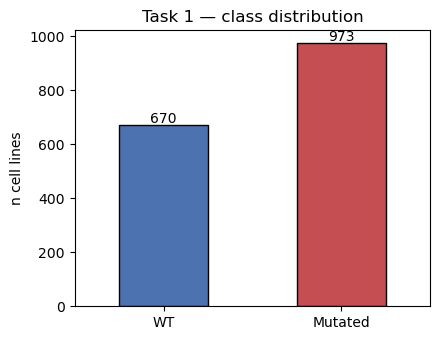

In [3]:
# Controlliamo la distribuzione delle classi
label_counts = (master['task1_tp53_mutated'].value_counts().sort_index() .rename(index={0: 'WT', 1: 'Mutated'}) .to_frame('n'))
# Aggiungiamo la percentuale per leggere meglio la distribuzione
label_counts['pct'] = (label_counts['n'] / label_counts['n'].sum() * 100).round(1)
display(label_counts)

fig, ax = plt.subplots(figsize=(4.5, 3.5))
label_counts['n'].plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'], edgecolor='black')

ax.set_title('Task 1 — class distribution')
ax.set_ylabel('n cell lines')
ax.set_xlabel('')

for i, v in enumerate(label_counts['n']):
    ax.text(i, v + 8, str(v), ha='center')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.2 Training design — train/val/test split

We replace the initial 80/20 train/val split with a proper **60/20/20 train / val / test** stratified split.

- **train** is used to fit the model
- **val** is the set we look at during development (model choice, hyperparameters)
- **test** is held out and only used to report the final number

Stratification preserves the WT / Mutated class proportions in all three splits.
Class weighting is `balanced` for consistency across experiments.

,model,fit_time_s,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Logistic Regression,39.4,0.8632,0.8947,0.8718,0.8831,0.9132,0.8450,0.8495,0.8974,0.8728,0.8918
1,Random Forest,5.8,0.8389,0.8227,0.9282,0.8723,0.8839,0.7933,0.7613,0.9487,0.8447,0.8799
2,XGBoost,168.3,0.8936,0.8883,0.9385,0.9127,0.9261,0.8815,0.8645,0.9487,0.9046,0.9231


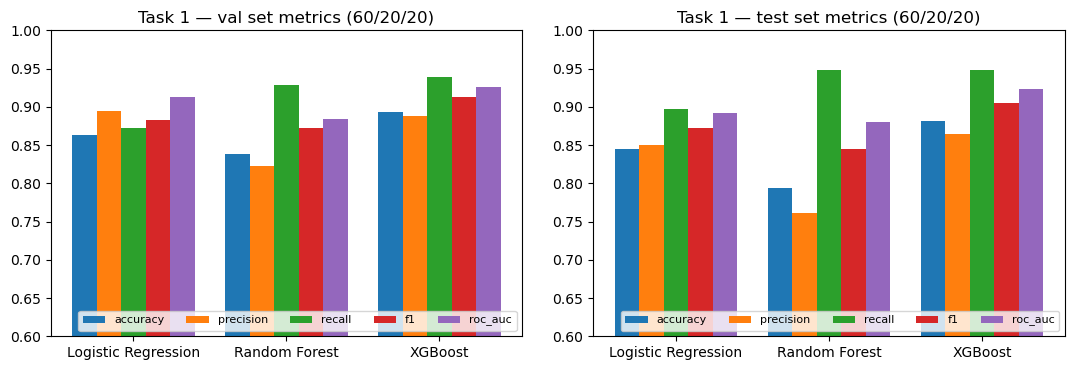

In [4]:
# 60/20/20 stratified split su tutti e 3 i modelli (val + test)
task1_baseline = pd.read_csv(OUTPUT_DIR / 'task1/baseline_split.csv')
display(task1_baseline.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for ax, split in zip(axes, ['val', 'test']):
    x = np.arange(len(task1_baseline))
    width = 0.16
    for i, m in enumerate(metrics):
        ax.bar(x + i*width, task1_baseline[f'{split}_{m}'], width, label=m)
    ax.set_xticks(x + 2*width)
    ax.set_xticklabels(task1_baseline['model'], rotation=0)
    ax.set_ylim(0.6, 1.0)
    ax.set_title(f'Task 1 — {split} set metrics (60/20/20)')
    ax.legend(loc='lower right', fontsize=8, ncol=5)
plt.tight_layout(); plt.show()

**Why 60/20/20?** We compared four split sizes on the same task (LogReg, 5 seed per ratio):

- larger train sets push mean test AUC up: 50/25/25 -> ~0.88, 80/10/10 -> ~0.91
- but smaller val and test sets (80/10/10) give us only ~165 samples per held-out fold, which is too few to estimate AUC reliably (per-seed std on test ~0.018)
- 50/25/25 sacrifices too much training data and the model underperforms

60/20/20 is the working compromise: large enough val (329 samples) and test (329 samples) to have a stable held-out estimate, and a training set of ~985 samples that is still big enough for the models to fit well.

,ratio,n_train,val_auc_mean,val_auc_std,test_auc_mean,test_auc_std
0,50/25/25,821,0.8887,0.0277,0.8801,0.0090
1,60/20/20,985,0.8975,0.0198,0.8967,0.0135
2,70/15/15,1150,0.8960,0.0114,0.9071,0.0234
3,80/10/10,1314,0.8920,0.0099,0.9101,0.0202


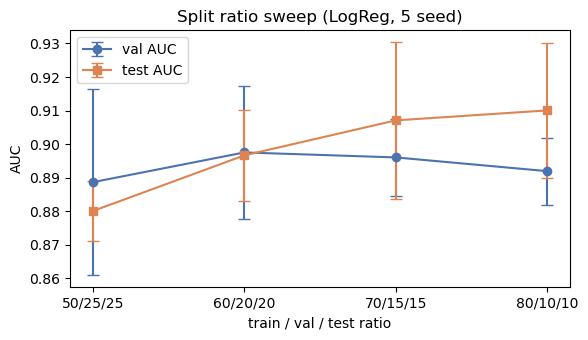

In [5]:
# Aggreghiamo il ratio experiment: mean +- std di val_auc e test_auc per ogni ratio
split_ratios = pd.read_csv(OUTPUT_DIR / 'task1/split_ratios.csv')
agg = (split_ratios
       .groupby(['train_pct', 'val_pct', 'test_pct'])
       .agg(val_auc_mean=('val_auc', 'mean'), val_auc_std=('val_auc', 'std'),
            test_auc_mean=('test_auc', 'mean'), test_auc_std=('test_auc', 'std'),
            n_train=('n_train', 'first'))
       .reset_index())
agg['ratio'] = agg.apply(lambda r: f"{int(r.train_pct)}/{int(r.val_pct)}/{int(r.test_pct)}", axis=1)
display(agg[['ratio', 'n_train', 'val_auc_mean', 'val_auc_std', 'test_auc_mean', 'test_auc_std']].round(4))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.errorbar(agg['ratio'], agg['val_auc_mean'], yerr=agg['val_auc_std'],
            fmt='o-', capsize=4, label='val AUC', color='#4C72B0')
ax.errorbar(agg['ratio'], agg['test_auc_mean'], yerr=agg['test_auc_std'],
            fmt='s-', capsize=4, label='test AUC', color='#DD8452')
ax.set_ylabel('AUC'); ax.set_xlabel('train / val / test ratio')
ax.set_title('Split ratio sweep (LogReg, 5 seed)')
ax.legend()
plt.tight_layout(); plt.show()

### 4.3 K-fold choice (3 / 5 / 10)

To justify the choice of 5-fold cross-validation, we ran StratifiedKFold with `k = 3, 5, 10` on Logistic Regression, repeating each with 5 random seeds.

The trade-off:
- small `k` → larger training folds in absolute terms but **fewer** folds, so each fold AUC depends more on which samples ended up in test
- large `k` → more folds (more stable mean), but each test fold is small (~165 samples for k=10), so per-fold AUC varies more
- runtime grows roughly linearly with `k`

We pick **5-fold** as the working setting: the mean AUC is essentially the same as `k=10` (0.901 vs 0.902), the per-fold variance is half of `k=10` (0.012 vs 0.022), and the runtime is also about half. `k=3` underfits slightly (AUC drops to 0.894 because each training fold is smaller and the per-seed variance is the largest of the three).

,k,mean_auc_across_seeds,std_auc_across_seeds,mean_std_per_fold,mean_time_s,total_time_s
0,3,0.8941,0.0027,0.0060,28.1579,140.7894
1,5,0.9007,0.0012,0.0118,83.0709,415.3543
2,10,0.9018,0.0009,0.0222,145.1725,725.8626


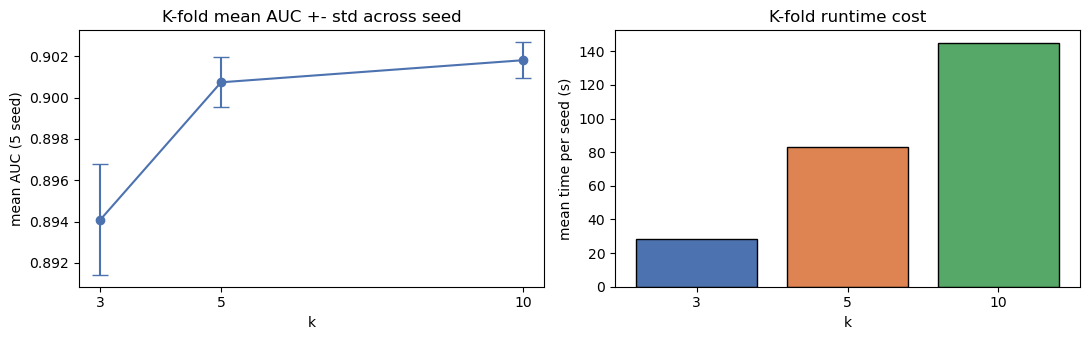

In [6]:
kfold = pd.read_csv(OUTPUT_DIR / 'task1/kfold_sweep.csv')
display(kfold.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].errorbar(kfold['k'], kfold['mean_auc_across_seeds'],
                 yerr=kfold['std_auc_across_seeds'],
                 fmt='o-', capsize=6, color='#4C72B0')
axes[0].set_xticks(kfold['k'])
axes[0].set_xlabel('k'); axes[0].set_ylabel('mean AUC (5 seed)')
axes[0].set_title('K-fold mean AUC +- std across seed')

axes[1].bar(kfold['k'].astype(str), kfold['mean_time_s'],
            color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
axes[1].set_xlabel('k'); axes[1].set_ylabel('mean time per seed (s)')
axes[1].set_title('K-fold runtime cost')
plt.tight_layout(); plt.show()

### 4.4 Hyperparameter search

We run a `RandomizedSearchCV` (30 iterations, 5-fold inner CV, scoring = ROC-AUC) on the three models, using the **top-2000 genes by variance** computed on the training set only.

Search spaces:

| Model | Hyperparameters |
|---|---|
| LogReg | `C` (log-uniform 1e-3..1e2), `penalty` (l1, l2) |
| RandomForest | `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features` |
| XGBoost | `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda` |

The best model is then refit on the full training set and evaluated on val and test.

The search is run via `scripts/train_task1_hpsearch.py` (HPC submission template in `scripts/hpc/run_hpsearch_ccle.sbatch`).

,model,cv_auc,val_auc,test_auc,val_f1,test_f1,search_time_s
0,LogReg,0.8917,0.9044,0.9036,0.8808,0.8769,51.5
1,RandomForest,0.8810,0.9030,0.8965,NaN,NaN,971.7


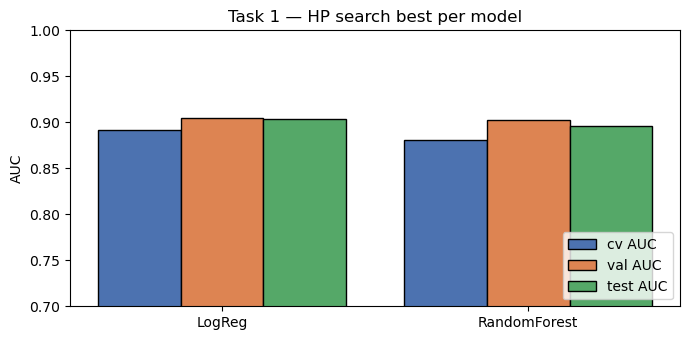

LogReg          best: {"clf__C": 0.0745934328572655, "clf__penalty": "l1", "clf__solver": "liblinear"}
RandomForest    best: {"clf__max_depth": null, "clf__max_features": 0.3, "clf__min_samples_leaf": 2, "clf__min_samples_split": 9, "clf__n_estimators": 587}


In [7]:
hp_path = OUTPUT_DIR / 'task1/hp_search_best.csv'
if hp_path.exists():
    hp = pd.read_csv(hp_path)
    display(hp[['model', 'cv_auc', 'val_auc', 'test_auc', 'val_f1', 'test_f1', 'search_time_s']].round(4))

    fig, ax = plt.subplots(figsize=(7, 3.5))
    x = np.arange(len(hp))
    w = 0.27
    ax.bar(x - w, hp['cv_auc'],   w, label='cv AUC',   color='#4C72B0', edgecolor='black')
    ax.bar(x,     hp['val_auc'],  w, label='val AUC',  color='#DD8452', edgecolor='black')
    ax.bar(x + w, hp['test_auc'], w, label='test AUC', color='#55A868', edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(hp['model'])
    ax.set_ylim(0.7, 1.0); ax.set_ylabel('AUC')
    ax.set_title('Task 1 — HP search best per model')
    ax.legend(loc='lower right')
    plt.tight_layout(); plt.show()

    for _, row in hp.iterrows():
        print(f"{row['model']:14s}  best: {row['best_params']}")
else:
    print('HP search results not yet available.')
    print('Run via: sbatch scripts/hpc/run_hpsearch_ccle.sbatch  (HPC)')
    print('Or:     python scripts/train_task1_hpsearch.py  (locale, ~30 min)')

### 4.5 Cross-validation with tissue control

To make the evaluation more robust, we repeated Task 1 under three validation settings (`train_task1_cv.py`):

| Scenario | Setup | Purpose |
|---|---|---|
| **A** | StratifiedKFold (5-fold) | Standard in-distribution evaluation |
| **B** | GroupKFold by tissue | Test generalization to unseen tissues |
| **C** | Tissue-only baseline | Measure how much prediction comes from tissue identity alone |

This comparison helps us separate a true TP53-related expression signal from tissue-specific effects.

,scenario,mean_auc,std_auc
0,A) Standard 5-fold CV,0.8981,0.0168
1,B) GroupKFold per tessuto,0.8489,0.0557
2,C) Tissue-only baseline,0.7533,0.0276


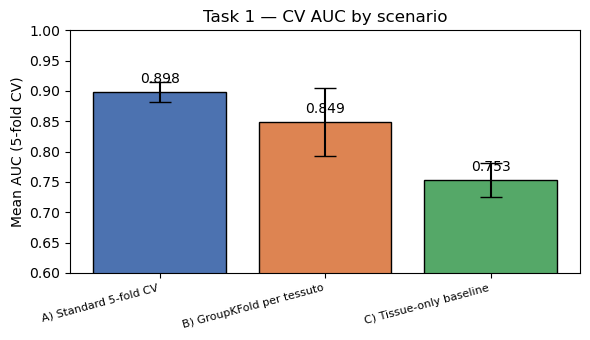

In [8]:
# Risultati della cross-validation nei tre scenari
cv_path = OUTPUT_DIR / 'task1/cv_comparison.csv'
if cv_path.exists():
    task1_cv = pd.read_csv(cv_path)
    display(task1_cv.round(4))

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(task1_cv['scenario'], task1_cv['mean_auc'], yerr=task1_cv['std_auc'],
           capsize=8, color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
    ax.set_ylim(0.6, 1.0)
    ax.set_ylabel('Mean AUC (5-fold CV)')
    ax.set_title('Task 1 — CV AUC by scenario')
    ax.tick_params(axis='x', labelsize=8)

    for i, v in enumerate(task1_cv['mean_auc']):
        ax.text(i, v + 0.015, f'{v:.3f}', ha='center')

    plt.xticks(rotation=15, ha='right')
    plt.tight_layout(); plt.show()
else:
    print('cv_comparison.csv not yet available — run scripts/train_task1_cv.py')


The three scenarios give a more complete view of model performance:

- **Scenario A** shows that the model performs well under standard cross-validation.
- **Scenario B** shows a moderate drop when tissues in the test set are not seen during training.
- **Scenario C** shows that tissue identity alone already carries some predictive signal.

Overall, these results suggest that part of the performance is related to tissue context, but gene expression still provides additional information beyond tissue alone.

### 4.6 Per-tissue breakdown

Using `LeaveOneGroupOut`, we evaluate the model with a leave-one-tissue-out strategy.  
Only tissues with at least 15 samples and both classes represented are included.

,tissue,n,n_mut,mut_rate_%,auc
0,Eye,23,1,4.3,1.000
1,Bladder/Urinary Tract,37,29,78.4,0.987
2,Uterus,43,29,67.4,0.953
3,Skin,119,38,31.9,0.951
4,Pleura,22,4,18.2,0.931
5,Thyroid,22,16,72.7,0.917
6,Ovary/Fallopian Tube,66,49,74.2,0.916
7,Bowel,84,64,76.2,0.890
8,CNS/Brain,96,60,62.5,0.885
9,Soft Tissue,77,29,37.7,0.846


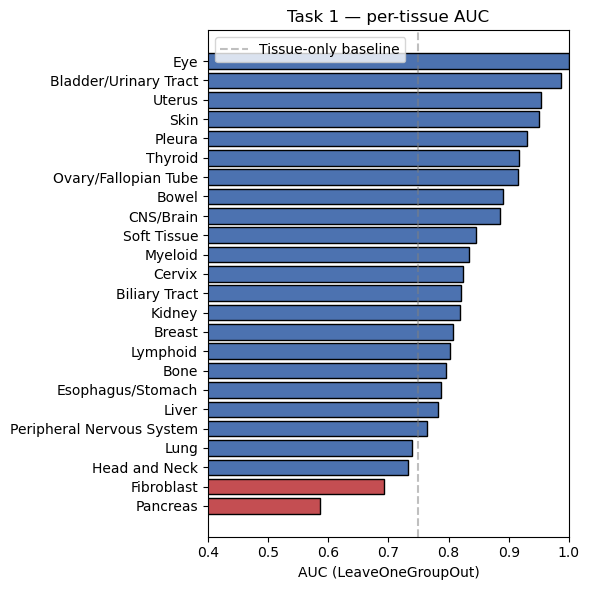

In [9]:
# Carico l'AUC ottenuta lasciando fuori un tessuto alla volta
tissue_path = OUTPUT_DIR / 'task1/per_tissue_auc.csv'
if tissue_path.exists():
    task1_tissue = pd.read_csv(tissue_path)
    display(task1_tissue.sort_values('auc', ascending=False).round(3))

    fig, ax = plt.subplots(figsize=(6, 6))
    tissue_sorted = task1_tissue.sort_values('auc')
    colors = ['#C44E52' if a < 0.7 else '#4C72B0' for a in tissue_sorted['auc']]

    ax.barh(tissue_sorted['tissue'], tissue_sorted['auc'], color=colors, edgecolor='black')
    ax.axvline(0.75, color='gray', linestyle='--', alpha=0.5, label='Tissue-only baseline')
    ax.set_xlim(0.4, 1.0)
    ax.set_xlabel('AUC (LeaveOneGroupOut)')
    ax.set_title('Task 1 — per-tissue AUC')
    ax.legend()
    plt.tight_layout(); plt.show()
else:
    print('per_tissue_auc.csv not yet available — run scripts/train_task1_cv.py')


**Tissue outliers**

- **Pancreas** is the clearest low-performance case.
- **Lung** and **Head & Neck** are less stable because the WT class is relatively small.

These cases suggest that class imbalance and tissue-specific biology can affect generalization.

### 4.7 Feature importance

We inspect feature importance to check if the model is using biologically meaningful genes.

In particular, if the classifier is capturing a real TP53-related signal, we expect important features to include genes from the p53 pathway and its downstream transcriptional targets.

In [10]:
rf_path = OUTPUT_DIR / 'task1/rf_feature_importance.csv'
xgb_path = OUTPUT_DIR / 'task1/xgb_feature_importance.csv'

# Lista di geni noti del pathway / regolazione p53 usata come controllo biologico
p53_canonical = {'MDM2', 'MDM4', 'CDKN1A', 'BAX', 'BBC3', 'PMAIP1', 'DDB2', 'RRM2B', 'ZMAT3', 'SESN1', 'SESN2', 'GADD45A',
                 'FDXR', 'PHLDA3', 'AEN', 'TNFRSF10B', 'RPS27L', 'SPATA18', 'BTG2', 'TP53I3', 'TP53AIP1', 'CCNG1', 'XPC',
                 'PERP', 'FAS', 'EDA2R'}

if rf_path.exists() and xgb_path.exists():
    rf_imp = pd.read_csv(rf_path)
    xgb_imp = pd.read_csv(xgb_path)

    rf_top20 = rf_imp.head(20).copy()
    rf_top20['canonical_p53_target'] = rf_top20['feature'].isin(p53_canonical)
    print('Random Forest — top 20 features:')
    display(rf_top20)
    print(f'\nCanonical p53 targets in RF top-20: {rf_top20["canonical_p53_target"].sum()}/20')

    xgb_top20 = xgb_imp.head(20).copy()
    xgb_top20['canonical_p53_target'] = xgb_top20['feature'].isin(p53_canonical)
    print('\nXGBoost — top 20 features:')
    display(xgb_top20)
    print(f'\nCanonical p53 targets in XGBoost top-20: {xgb_top20["canonical_p53_target"].sum()}/20')
else:
    print('feature_importance CSV not yet available — run scripts/train_task1.py')


Random Forest — top 20 features:


,feature,importance,canonical_p53_target
0,MDM2,0.012198,True
1,EDA2R,0.006890,True
2,ZMAT3,0.006320,True
3,PTCHD4,0.006003,False
4,AEN,0.005579,True
5,CDKN1A,0.005475,True
6,FDXR,0.004746,True
7,SPATA18,0.004199,True
8,SESN1,0.004048,True
9,PHLDA3,0.003769,True



Canonical p53 targets in RF top-20: 15/20

XGBoost — top 20 features:


,feature,importance,canonical_p53_target
0,EDA2R,0.006197,True
1,TSC22D2,0.004941,False
2,OTX1,0.004645,False
3,HEATR4,0.003847,False
4,CADM3,0.003717,False
5,GPNMB,0.003649,False
6,CPSF4,0.002856,False
7,CADPS,0.002761,False
8,GAB1,0.002647,False
9,ACTR8,0.002506,False



Canonical p53 targets in XGBoost top-20: 3/20


The feature-importance analysis is consistent with the biological role of TP53.

Several top-ranked genes are known p53-related targets, which suggests that the model is not relying only on arbitrary patterns in the data. At the same time, some model-specific differences remain, especially for XGBoost, which may also capture part of the tissue-related structure already discussed above.

### 4.8 Gene-level correlation with TP53 status

As a model-free analysis, we look at the per-gene correlation with the binary TP53 label.
We use **Spearman** correlation (rank-based) instead of Pearson, because Pearson assumes a linear relationship and is sensitive to outliers in the expression values, while Spearman captures monotonic relationships and is robust to outliers.

We also compute Pearson for direct comparison, so we can see where the two metrics agree and where they don't.

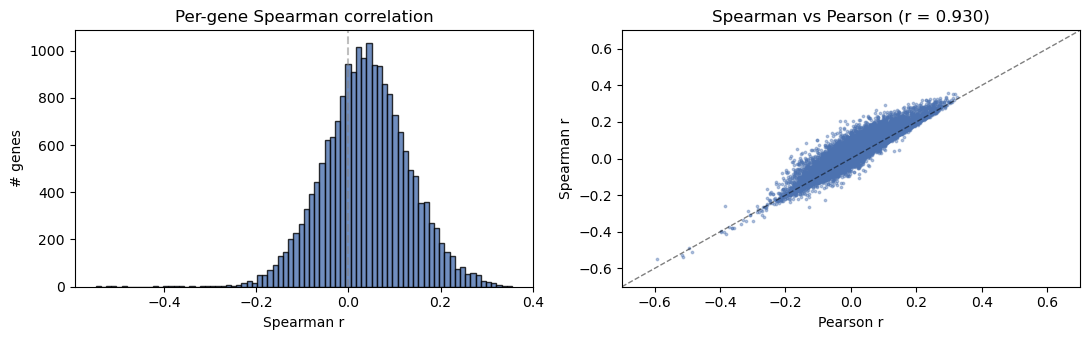

Top 15 geni con espressione piu bassa nei TP53-mutati (Spearman):


,gene,spearman_r
0,EDA2R,-0.548362
1,MDM2,-0.538430
2,RPS27L,-0.524165
3,CDKN1A,-0.512063
4,ZMAT3,-0.488110
5,PTCHD4,-0.414090
6,BAX,-0.401394
7,SESN1,-0.400008
8,RRM2B,-0.396300
9,CCNG1,-0.379253



Geni con la differenza piu grande |spearman - pearson|:


,gene,pearson_r,spearman_r,delta,abs_delta
0,CCL22,-0.0343,0.2064,0.2407,0.2407
1,RBP3,-0.0170,0.2067,0.2237,0.2237
2,ITIH6,-0.1368,0.0837,0.2206,0.2206
3,SLC45A2,-0.1646,0.0533,0.2180,0.2180
4,DNTT,-0.1042,0.1009,0.2051,0.2051
5,ROPN1B,-0.1033,0.1014,0.2047,0.2047
6,DSPP,-0.0341,0.1657,0.1997,0.1997
7,LRRN4,-0.0120,0.1873,0.1993,0.1993
8,TYR,-0.1821,0.0164,0.1985,0.1985
9,VRTN,-0.0728,0.1235,0.1963,0.1963


In [11]:
spear = pd.read_csv(OUTPUT_DIR / 'task1/gene_correlation_spearman.csv')
pear  = pd.read_csv(OUTPUT_DIR / 'task1/gene_correlation_pearson.csv')
comp  = pd.read_csv(OUTPUT_DIR / 'task1/gene_correlation_comparison.csv')

# distribuzione Spearman + scatter Spearman vs Pearson
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(spear['spearman_r'], bins=80, color='#4C72B0', edgecolor='black', alpha=0.8)
axes[0].axvline(0, c='gray', ls='--', alpha=0.5)
axes[0].set_xlabel('Spearman r'); axes[0].set_ylabel('# genes')
axes[0].set_title('Per-gene Spearman correlation')

axes[1].scatter(comp['pearson_r'], comp['spearman_r'], s=3, alpha=0.4, color='#4C72B0')
lims = (-0.7, 0.7); axes[1].plot(lims, lims, 'k--', alpha=0.5, lw=1)
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_xlabel('Pearson r'); axes[1].set_ylabel('Spearman r')
agree = np.corrcoef(comp['pearson_r'], comp['spearman_r'])[0, 1]
axes[1].set_title(f'Spearman vs Pearson (r = {agree:.3f})')
plt.tight_layout(); plt.show()

print('Top 15 geni con espressione piu bassa nei TP53-mutati (Spearman):')
display(spear.head(15).reset_index(drop=True))

print('\nGeni con la differenza piu grande |spearman - pearson|:')
display(comp.sort_values('abs_delta', ascending=False).head(10).round(4).reset_index(drop=True))

The two metrics broadly agree (overall correlation ~0.93), and the genes most negatively correlated with TP53 mutation — those with consistently lower expression in TP53-mutated samples — match the known p53 targets we already saw in the feature-importance ranking.

However, the **largest disagreements** are on genes driven by strong tissue-specific outliers (e.g. melanin pathway: `TYR`, `SLC45A2`; melanoma-related: `DSPP`, `ROPN1B`), where Pearson is pulled by a handful of extreme values while Spearman, which works on ranks, is not. This is exactly the kind of confound Spearman is supposed to remove.

### 4.9 MLP (PyTorch) — Task 1

We add a multi-layer perceptron to the model roster to test whether depth helps over the linear and tree-based classifiers. 
The goal is not to optimize a deep architecture, but to test whether a neural-network model can improve over the simpler baselines.

Main settings:
- two hidden layers
- batch normalization and dropout
- cross-entropy loss with class weights
- Adam optimizer
- 5-fold cross-validation

In [12]:
if RUN_HEAVY:
    print('Run `python scripts/compute_mlp.py` to (re)generate the MLP CSVs.')

# Carichiamo i risultati gia salvati del modello MLP
mlp_path = OUTPUT_DIR / 'task1/mlp_results.csv'
cm_path = OUTPUT_DIR / 'task1/mlp_confusion_matrix.csv'
if mlp_path.exists() and cm_path.exists():
    mlp_t1 = pd.read_csv(mlp_path)
    cm_t1 = pd.read_csv(cm_path, index_col=0)
    display(mlp_t1.round(4))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm_t1, annot=True, fmt='d', cmap='Blues', cbar=False,
                ax=ax, square=True)
    ax.set_title('Task 1 — MLP confusion matrix (5-fold CV)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout(); plt.show()
else:
    print('MLP Task 1 not yet computed.')
    print('Run via: sbatch scripts/hpc/run_mlp.sbatch  (HPC)')


MLP Task 1 not yet computed.
Run via: sbatch scripts/hpc/run_mlp.sbatch  (HPC)


The MLP performs similarly to the classical models, but it doesn't give a significant improvement.

So we consider that the simpler tree-based and linear baselines are sufficient for this task. In this dataset, increasing model complexity does not seem to add much beyond what is already captured by the standard approaches.

## 5. Task 2 — Multi-class classification of mutation type

### 5.1 Two label definitions

There are **two distinct ways** to classify a mutation:

**A. Coding consequence (protein-level, Sequence Ontology):**
synonymous, missense, nonsense (stop-gained), in-frame insertion / deletion, frameshift, start lost, stop lost, …

**B. DNA-level (nucleotide mechanism):**
SNV (single nucleotide variant), MNV (multi-nucleotide), insertion, deletion.

We keep both definitions and compare them using the same modelling pipeline.  
The goal is to understand which label structure is more consistent with gene expression data.

Operational labels:

| Coding consequence | DNA-level |
|---|---|
| `WT` | `WT` |
| `Missense` | `SNV` |
| `Inframe` | `MNV` (DepMap calls these `substitution`) |
| `Truncating` (nonsense + frameshift + splice site) | `Insertion` |
| | `Deletion` |

When a cell line has multiple TP53 mutations, we assign one representative label using the most severe coding consequence. The corresponding DNA-level type is then taken from the same mutation.

In [13]:
# Carichiamo le label del Task 2 gia costruite
labels = pd.read_csv(OUTPUT_DIR / 'datasets/task2_labels.csv')
print(f'Task 2 labels file: {labels.shape}')
display(labels.head(8))

Task 2 labels file: (1643, 10)


,ModelID,task1_tp53_mutated,task2_mutation_type,task2_mutation_type_int,task2_dna_type,task2_dna_type_int,n_tp53_mutations,worst_variant_type,worst_variant_info,worst_protein_change
0,ACH-001113,1,Missense,1,SNV,1,1,SNV,missense_variant,p.M237I
1,ACH-001289,0,WT,0,WT,0,0,NaN,NaN,NaN
2,ACH-001339,1,Missense,1,SNV,1,1,SNV,missense_variant,p.C135R
3,ACH-001979,0,WT,0,WT,0,0,NaN,NaN,NaN
4,ACH-002438,0,WT,0,WT,0,0,NaN,NaN,NaN
5,ACH-001538,0,WT,0,WT,0,0,NaN,NaN,NaN
6,ACH-000242,0,WT,0,WT,0,0,NaN,NaN,NaN
7,ACH-000708,0,WT,0,WT,0,0,NaN,NaN,NaN


### 5.2 Distribution of both taxonomies


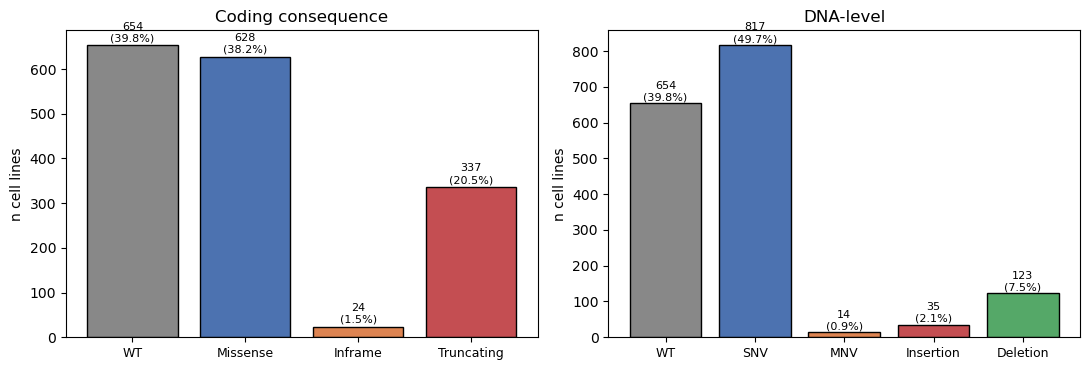

,coding_consequence_n,coding_consequence_pct
task2_mutation_type,,
WT,654,39.8
Missense,628,38.2
Inframe,24,1.5
Truncating,337,20.5


,dna_level_n,dna_level_pct
task2_dna_type,,
WT,654,39.8
SNV,817,49.7
MNV,14,0.9
Insertion,35,2.1
Deletion,123,7.5


In [14]:
# Confrontiamo la distribuzione delle classi nelle due tassonomie

coding_order = ['WT', 'Missense', 'Inframe', 'Truncating']
dna_order = ['WT', 'SNV', 'MNV', 'Insertion', 'Deletion']

coding_dist = labels['task2_mutation_type'].value_counts().reindex(coding_order)
dna_dist = labels['task2_dna_type'].value_counts().reindex(dna_order)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for ax, dist, title in zip(axes, [coding_dist, dna_dist], ['Coding consequence', 'DNA-level']):
    bars = ax.bar(dist.index, dist.values, color=['#888', '#4C72B0', '#DD8452', '#C44E52', '#55A868'][:len(dist)],
                  edgecolor='black')
    
    ax.set_title(title)
    ax.set_ylabel('n cell lines')

    for bar, v in zip(bars, dist.values):
        pct = 100 * v / dist.sum()
        ax.text(bar.get_x() + bar.get_width()/2, v + 8, f'{v}\n({pct:.1f}%)', ha='center', fontsize=8)

    plt.setp(ax.get_xticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

summary_df = pd.concat([coding_dist.to_frame('coding_consequence_n'),(coding_dist / coding_dist.sum() * 100).round(1).to_frame('coding_consequence_pct'),
], axis=1)

display(summary_df)

summary_df = pd.concat([dna_dist.to_frame('dna_level_n'), (dna_dist / dna_dist.sum() * 100).round(1).to_frame('dna_level_pct'),
], axis=1)
display(summary_df)


### 5.3 Crosstab DNA × Coding

The same physical mutations re-labeled both ways:


In [15]:
# Tabella incrociata tra tassonomia DNA-level e coding consequence

ct = pd.crosstab(labels['task2_dna_type'], labels['task2_mutation_type'], margins=True, margins_name='Total')
ct = ct.reindex(index=['WT', 'SNV', 'MNV', 'Insertion', 'Deletion', 'Total'], columns=['WT', 'Missense', 'Inframe', 'Truncating', 'Total'],)

display(ct.fillna(0).astype(int))

task2_mutation_type,WT,Missense,Inframe,Truncating,Total
task2_dna_type,,,,,
WT,654,0,0,0,654
SNV,0,619,0,198,817
MNV,0,9,0,5,14
Insertion,0,0,3,32,35
Deletion,0,0,21,102,123
Total,654,628,24,337,1643


The crosstab already suggests an important difference between the two label definitions.

- The **DNA-level taxonomy** groups together mutations that may have very different functional effects.
- The **coding-consequence taxonomy** is closer to the expected biological impact on the protein.

Since gene expression is more likely to reflect functional consequences rather than the exact DNA mechanism, we expect the coding-based labels to be easier to predict.

### 5.4 Dropping rare classes

Some classes are too small to support stable multi-class training.

In particular:
- `Inframe` is rare in the coding-consequence taxonomy
- `MNV` is rare in the DNA-level taxonomy

We therefore remove classes with fewer than 30 samples before training.  
This is a conservative choice: it avoids training on classes with too little data and keeps the comparison more reliable.

After filtering:
- coding consequence becomes a 3-class problem
- DNA-level mutation type becomes a 4-class problem

**Why we drop Inframe.**  
Beyond the sample-count threshold, we also checked whether the Inframe class forms a stable group in feature space. Using a PCA-based representation, its centroid is not clearly separated from the other mutated classes, which supports excluding it from training.

In [16]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import itertools

# Unire labels e master
master_for_eda = master.drop(columns=['task2_mutation_type'], errors='ignore')
df_eda = master_for_eda.merge(labels[['ModelID', 'task2_mutation_type']], on='ModelID', how='inner')
df_eda = df_eda[df_eda['task2_mutation_type'].isin(['Missense', 'Inframe', 'Truncating'])]

metadata_cols = {'ModelID', 'CellLineName', 'CCLEName', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype',
    'Sex', 'AgeCategory', 'PrimaryOrMetastasis', 'SequencingID', 'ModelConditionID', 'IsDefaultEntryForMC', 'IsDefaultEntryForModel', 'IsDefaultEntryForModel_bool',
    'TP53_expression', 'TP53_damaging_score','task1_tp53_mutated', 'task2_mutation_type'}

feature_cols_eda = [c for c in df_eda.columns if c not in metadata_cols]

X_pca = PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(
    StandardScaler().fit_transform(SimpleImputer(strategy='median').fit_transform(df_eda[feature_cols_eda].values))
)
y_eda = df_eda['task2_mutation_type'].values

centroids = {c: X_pca[y_eda == c].mean(axis=0) for c in ['Missense', 'Inframe', 'Truncating']}
rows = []
for a, b in itertools.combinations(['Missense', 'Inframe', 'Truncating'], 2):
    rows.append({'pair': f'{a} vs {b}', 'distance_PCA50': round(float(np.linalg.norm(centroids[a] - centroids[b])), 2),})

centroid_distances = pd.DataFrame(rows).sort_values('distance_PCA50').reset_index(drop=True)
display(centroid_distances)

,pair,distance_PCA50
0,Missense vs Truncating,7.47
1,Missense vs Inframe,17.09
2,Inframe vs Truncating,17.81


In practice, the Inframe centroid is almost equidistant from Missense and Truncating.  
This suggests that the class is too small and unstable to define a reliable decision boundary, so removing it is more reasonable than forcing the model to learn it.

### 5.5 Training — same pipeline on both labels

We train the same three classifiers on both label definitions:
- Logistic Regression
- Random Forest
- XGBoost

All models are evaluated with stratified 5-fold cross-validation.  
We keep the training pipeline as similar as possible across the two taxonomies so that the comparison depends mainly on the label definition, not on different modelling choices.

In [17]:
if RUN_HEAVY:
    # Rirunna l'intera pipeline della Task 2 (lenta)
    import subprocess, sys
    print('[RUN_HEAVY] Launching scripts/train_task2.py...')
    result = subprocess.run([sys.executable, 'scripts/train_task2.py'], capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print('STDERR:', result.stderr)
else:
    print('[skip] Loading pre-computed Task 2 results from output_tp53/.')
    print('       Set RUN_HEAVY=True at the top of the notebook to re-run.')

[skip] Loading pre-computed Task 2 results from output_tp53/.
       Set RUN_HEAVY=True at the top of the notebook to re-run.


### 5.6 Results — side-by-side comparison


In [18]:
# Confronto finale tra modelli e tra le due definizioni di label
tax_path = OUTPUT_DIR / 'task2/taxonomy_comparison.csv'
if tax_path.exists():
    task2 = pd.read_csv(tax_path)
    display(task2.round(4))
else:
    task2 = None
    print('task2/taxonomy_comparison.csv not yet available — run scripts/train_task2.py')


,label,model,n_classes,n_samples,accuracy,macro_f1,weighted_f1,f1_Missense,f1_Truncating,f1_WT,f1_Deletion,f1_Insertion,f1_SNV
0,coding,LogReg,3,1619,0.6479,0.6025,0.6453,0.6043,0.3836,0.8196,NaN,NaN,NaN
1,coding,RandomForest,3,1619,0.6170,0.4716,0.5557,0.6300,0.0287,0.7560,NaN,NaN,NaN
2,coding,XGBoost,3,1619,0.6726,0.5538,0.6309,0.6710,0.1505,0.8400,NaN,NaN,NaN
3,dna,LogReg,4,1629,0.7477,0.4539,0.7284,NaN,NaN,0.8113,0.0899,0.1304,0.7838
4,dna,RandomForest,4,1629,0.7256,0.3795,0.6869,NaN,NaN,0.7431,0.0000,0.0000,0.7748
5,dna,XGBoost,4,1629,0.7876,0.4285,0.7490,NaN,NaN,0.8390,0.0000,0.0556,0.8194


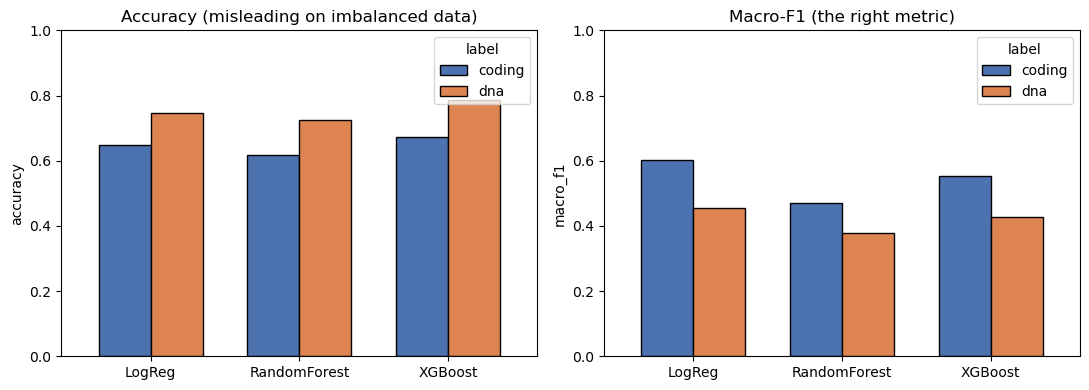

In [19]:
if task2 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    for ax, metric, title in zip(
        axes,
        ['accuracy', 'macro_f1'],
        ['Accuracy (misleading on imbalanced data)', 'Macro-F1 (the right metric)'],
    ):
        pivot = task2.pivot(index='model', columns='label', values=metric)
        pivot[['coding', 'dna']].plot(kind='bar', ax=ax, width=0.7, color=['#4C72B0', '#DD8452'], edgecolor='black')
        ax.set_title(title)
        ax.set_ylim(0, 1.0)
        ax.set_ylabel(metric)
        ax.set_xlabel('')
        plt.setp(ax.get_xticklabels(), rotation=0)
        ax.legend(title='label', loc='upper right')

    plt.tight_layout(); plt.show()


The results depend strongly on the evaluation metric.

- On **accuracy**, the DNA-level taxonomy may appear competitive.
- On **macro-F1**, the coding-consequence taxonomy performs better across models.

We focus on **macro-F1** because this is an imbalanced multi-class problem.  
Unlike accuracy, macro-F1 gives the same importance to each class and highlights whether the model is ignoring smaller classes.

### 5.7 Confusion matrices — where the errors go


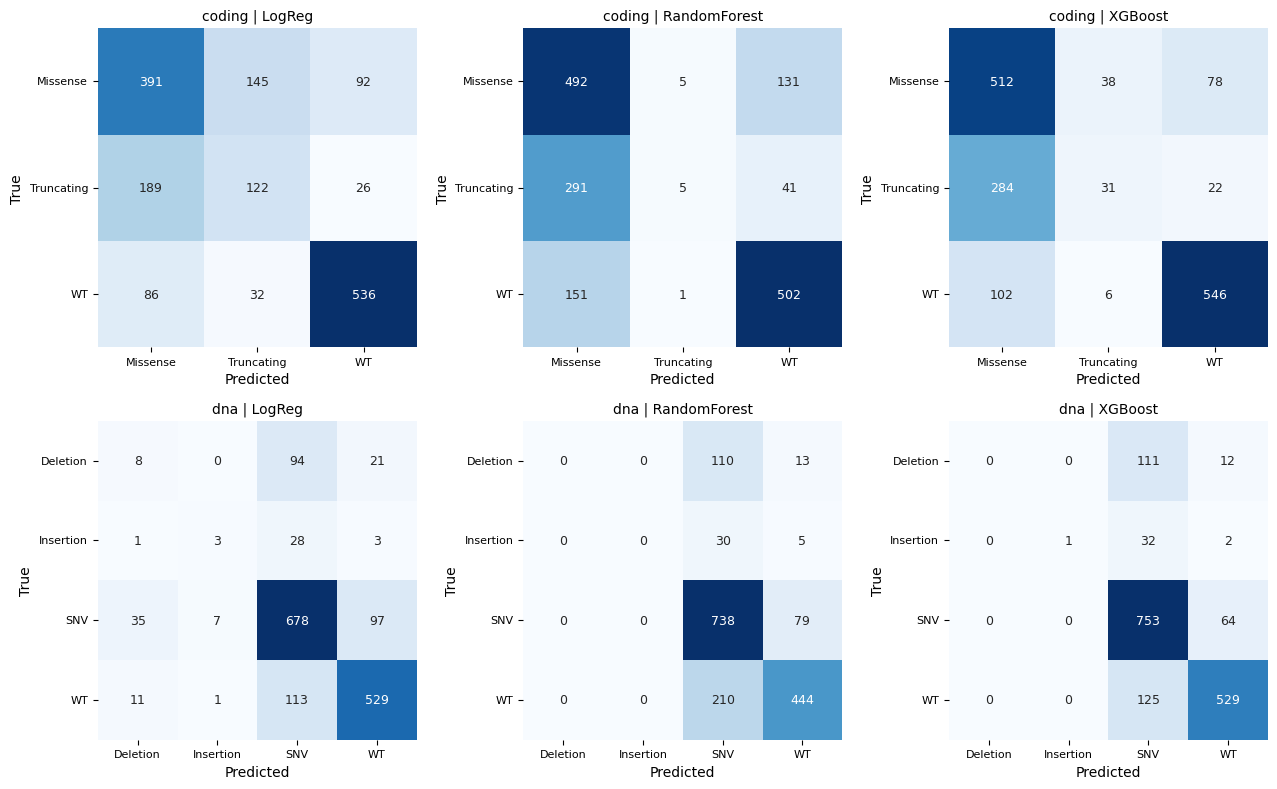

In [20]:
# Matrici di confusione per capire dove si concentrano gli errori
configs = [
    ('coding', 'LogReg'), ('coding', 'RandomForest'), ('coding', 'XGBoost'),
    ('dna',    'LogReg'), ('dna',    'RandomForest'), ('dna',    'XGBoost'),
]

available = [(l, m) for l, m in configs if (OUTPUT_DIR / f'task2/cm_{l}_{m}.csv').exists()]

if available:
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    for ax, (label_name, model_name) in zip(axes.flat, configs):
        cm_path = OUTPUT_DIR / f'task2/cm_{label_name}_{model_name}.csv'
        if cm_path.exists():
            cm = pd.read_csv(cm_path, index_col=0)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, square=True, ax=ax, annot_kws={'fontsize': 9})
            ax.set_title(f'{label_name} | {model_name}', fontsize=10)
            ax.set_xlabel('Predicted'); ax.set_ylabel('True')
            plt.setp(ax.get_xticklabels(), fontsize=8)
            plt.setp(ax.get_yticklabels(), fontsize=8, rotation=0)
        else:
            ax.axis('off'); ax.set_title(f'{label_name} | {model_name} (missing)', fontsize=10)
    plt.tight_layout(); plt.show()
else:
    print('No task2 confusion matrices yet — run scripts/train_task2.py')


**Key observations from the confusion matrices:**

**Coding consequence.**  
The models recover WT reasonably well, and they also identify many Missense samples.  
The most difficult class is Truncating, which is often confused with Missense. This is still biologically plausible, since both classes correspond to altered TP53 function.

**DNA-level taxonomy.**  
The rare classes are much harder to recover. In particular, some models almost never predict Insertion or Deletion, which suggests that the DNA-level labels are less aligned with the expression signal.

### 5.8 MLP (PyTorch) — Task 2 multi-class

As an additional comparison, we apply the same MLP architecture used in Task 1 to the coding-consequence labels after rare-class filtering.

The goal is not to build a highly optimized deep model, but to check whether a neural-network approach improves over the standard baselines on this multi-class setting.

In [21]:
# Carichiamo i risultati gia salvati dell'MLP sul Task 2

if RUN_HEAVY:
    print('Run `python scripts/compute_mlp.py` to (re)generate the MLP CSVs.')

mlp_path = OUTPUT_DIR / 'task2/mlp_results.csv'
cm_path = OUTPUT_DIR / 'task2/mlp_confusion_matrix.csv'
if mlp_path.exists() and cm_path.exists():
    mlp_t2 = pd.read_csv(mlp_path)
    cm_t2 = pd.read_csv(cm_path, index_col=0)
    display(mlp_t2.round(4))

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm_t2, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax, square=True)
    ax.set_title('Task 2 (coding) — MLP confusion matrix (5-fold CV)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout(); plt.show()

    # Confronto con i modelli classici
    task2_baseline = pd.read_csv(OUTPUT_DIR / 'task2/taxonomy_comparison.csv')
    coding_only = task2_baseline[task2_baseline['label'] == 'coding'][['model', 'accuracy', 'macro_f1', 'weighted_f1']]
    mlp_row = mlp_t2[['accuracy', 'macro_f1', 'weighted_f1']].copy()
    mlp_row.insert(0, 'model', 'MLP (PyTorch)')
    comparison = pd.concat([coding_only, mlp_row], ignore_index=True)
    print('\nAll Task 2 (coding 3-class) models, head to head:')
    display(comparison.round(4))
else:
    print('MLP Task 2 not yet computed.')
    print('Run via: sbatch scripts/hpc/run_mlp.sbatch  (HPC)')


MLP Task 2 not yet computed.
Run via: sbatch scripts/hpc/run_mlp.sbatch  (HPC)


The MLP achieves performance similar to the other models, with only a small difference in macro-F1.

Overall, this suggests that model complexity is not the main limitation in Task 2.  
The main difficulty comes from the structure of the labels and from the overlap between mutation classes in the expression space.

### 5.9 Summary of Task 2

Task 2 suggests that **coding consequence** is the more suitable label definition for prediction from gene expression.

Three points support this conclusion:
1. Macro-F1 is consistently higher for coding-consequence labels
2. The confusion matrices are more interpretable on the coding side
3. The DNA-level taxonomy makes the rare classes harder to separate

Overall, gene expression appears to reflect the functional impact of TP53 alterations more than the exact nucleotide-level mutation mechanism.

## 6. Extension to TCGA Pan-Cancer

To check whether the TP53 expression signal we observed in CCLE generalizes to patient samples, we extend the analysis to **TCGA Pan-Cancer Atlas** data (UCSC Xena hub).

We use two files:
- gene expression (batch-corrected RNA-seq, `EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp`)
- somatic mutations (`mc3.v0.2.8.PUBLIC` MAF)

After filtering to primary tumor samples and intersecting with the CCLE gene panel, we get **10,332 patient samples × 16,321 genes** across 33 cancer types.

The TP53 labels (Task 1 + Task 2 coding-consequence) are derived from the MC3 MAF using the same taxonomy used for CCLE.

TCGA samples: 10332
Cancer types: 33


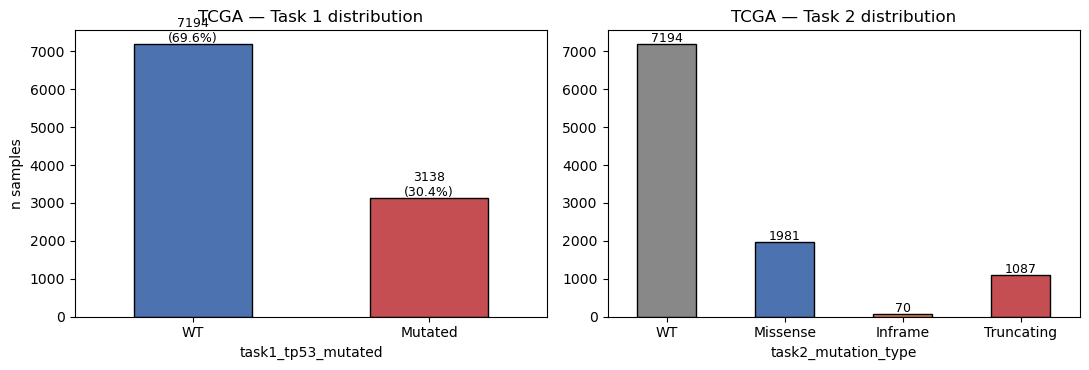

In [22]:
# Distribuzione delle label TCGA
tcga_labels = pd.read_csv(OUTPUT_DIR / 'datasets/tcga_master_labels.csv')
print(f'TCGA samples: {len(tcga_labels)}')
print(f'Cancer types: {tcga_labels["tcga_cancer_type"].nunique()}')

t1 = tcga_labels['task1_tp53_mutated'].value_counts().rename({0: 'WT', 1: 'Mutated'})
t2_order = ['WT', 'Missense', 'Inframe', 'Truncating']
t2 = tcga_labels['task2_mutation_type'].value_counts().reindex(t2_order)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
t1.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#C44E52'], edgecolor='black')
axes[0].set_title('TCGA — Task 1 distribution')
axes[0].set_ylabel('n samples')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(t1.values):
    axes[0].text(i, v + 50, f'{v}\n({100*v/t1.sum():.1f}%)', ha='center', fontsize=9)

t2.plot(kind='bar', ax=axes[1], color=['#888', '#4C72B0', '#DD8452', '#C44E52'], edgecolor='black')
axes[1].set_title('TCGA — Task 2 distribution')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(t2.values):
    axes[1].text(i, v + 50, f'{v}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

The class balance is different from CCLE: TCGA has **~30% TP53-mutated** vs **~59% in CCLE**.
This is consistent with the fact that CCLE is enriched for aggressive tumor lines where TP53 is more frequently lost, while TCGA also covers cancer types where TP53 is rarely mutated (e.g. THCA, PRAD).

The mutation-type distribution within mutated samples is similar: Missense >> Truncating > Inframe.

### 6.1 Transfer test — CCLE-trained models on TCGA

First we apply the models trained on the full CCLE set directly to TCGA samples, with **no TCGA retraining**.
This is the simplest cross-cohort check: does the gene-expression signature that worked on cell lines still work on patient tumors?

,model,n_ccle_train,n_tcga_test,accuracy,f1,roc_auc
0,LogReg,1643,10332,0.6277,0.5480,0.7119
1,RandomForest,1643,10332,0.3062,0.4653,0.4919
2,XGBoost,1643,10332,0.3037,0.4659,0.5338


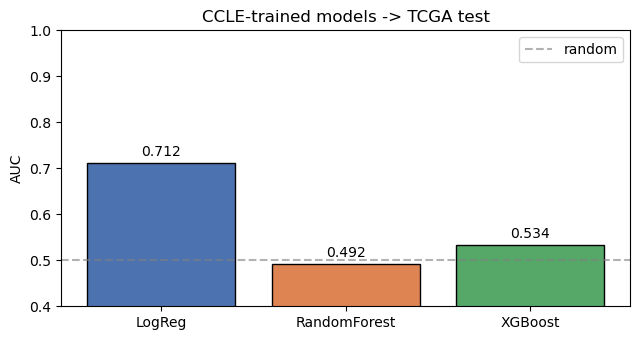

In [23]:
transfer = pd.read_csv(OUTPUT_DIR / 'tcga/transfer_metrics.csv')
display(transfer.round(4))

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(transfer['model'], transfer['roc_auc'],
       color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
ax.axhline(0.5, c='gray', ls='--', alpha=0.6, label='random')
ax.set_ylim(0.4, 1.0); ax.set_ylabel('AUC')
ax.set_title('CCLE-trained models -> TCGA test')
ax.legend(loc='upper right')
for i, v in enumerate(transfer['roc_auc']):
    ax.text(i, v + 0.015, f'{v:.3f}', ha='center')
plt.tight_layout(); plt.show()

The transfer test confirms that the signal generalizes to TCGA only for the **linear model**: Logistic Regression gives AUC ~0.71 on patient samples — well above random, but well below the in-domain CCLE numbers.

**Random Forest and XGBoost transfer worse.** Their tree-based decision boundaries pick up CCLE-specific patterns (tissue-type composition, sequencing batch effects) that are not present in TCGA. The class prior also differs (60% vs 30% mutated), which a tree ensemble does not adjust for as gracefully as a logistic baseline.

This motivates **retraining the same pipeline on TCGA**.

### 6.2 Retraining on TCGA

We apply the **same pipeline** used on CCLE on the TCGA samples:
- 60/20/20 stratified train/val/test split
- top-2000 genes by variance (computed on train)
- `RandomizedSearchCV` with the same search spaces

This is run on HPC via `scripts/train_tcga.py` and the SLURM template `scripts/hpc/run_train_tcga.sbatch`.

In [24]:
# Risultati del retraining su TCGA (output del job HPC)
tcga_hp_path = OUTPUT_DIR / 'tcga/tcga_hp_search_best.csv'
ccle_hp_path = OUTPUT_DIR / 'task1/hp_search_best.csv'

if tcga_hp_path.exists() and ccle_hp_path.exists():
    tcga_hp = pd.read_csv(tcga_hp_path)
    ccle_hp = pd.read_csv(ccle_hp_path)
    display(tcga_hp[['model', 'cv_auc', 'val_auc', 'test_auc', 'val_f1', 'test_f1']].round(4))

    joined = (ccle_hp[['model', 'test_auc']]
              .rename(columns={'test_auc': 'CCLE_test_auc'})
              .merge(tcga_hp[['model', 'test_auc']]
                     .rename(columns={'test_auc': 'TCGA_test_auc'}), on='model'))
    transfer = pd.read_csv(OUTPUT_DIR / 'tcga/transfer_metrics.csv')
    joined['transfer_test_auc'] = transfer.set_index('model').loc[joined['model'], 'roc_auc'].values
    display(joined.round(4))

    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    x = np.arange(len(joined))
    w = 0.27
    ax.bar(x - w, joined['CCLE_test_auc'],     w, label='CCLE in-domain',       color='#4C72B0', edgecolor='black')
    ax.bar(x,     joined['transfer_test_auc'], w, label='CCLE -> TCGA transfer', color='#DD8452', edgecolor='black')
    ax.bar(x + w, joined['TCGA_test_auc'],     w, label='TCGA in-domain',       color='#55A868', edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(joined['model'])
    ax.axhline(0.5, c='gray', ls='--', alpha=0.5)
    ax.set_ylim(0.4, 1.0); ax.set_ylabel('test AUC')
    ax.set_title('CCLE vs TCGA — confronto delle tre condizioni')
    ax.legend(loc='lower right')
    plt.tight_layout(); plt.show()
else:
    print('TCGA retraining results not yet available.')
    print('Run via: sbatch scripts/hpc/run_train_tcga.sbatch  (HPC)')
    print('Or:     python scripts/train_tcga.py  (locale, ~ore)')

TCGA retraining results not yet available.
Run via: sbatch scripts/hpc/run_train_tcga.sbatch  (HPC)
Or:     python scripts/train_tcga.py  (locale, ~ore)


### 6.3 Summary

The TCGA extension gives a more complete picture:

1. **In-domain CCLE** is the easiest setting (AUC ~0.90).
2. **Direct transfer CCLE -> TCGA** is hard: only the linear model preserves a meaningful signal (~0.71); tree ensembles collapse close to random.
3. **Retraining on TCGA** recovers a strong in-domain performance on patient samples, at a level comparable to CCLE.

So the **TP53 expression signature exists in patient tumors too**, but it is partly cohort-specific and gets masked by CCLE-specific batch effects when models trained on cell lines are applied as-is. A future step would be ComBat batch correction across cohorts.

## 7. Limitations

This project has a few important limitations.

1. **Tissue effects.** In Task 1 we showed that tissue identity already carries part of the predictive signal. This means that some of the performance may depend on tissue context and not only on TP53 status.

2. **Rare classes in Task 2.** Some mutation classes were too small to support stable multi-class training, so we removed them before fitting the models.

3. **Cross-cohort gap CCLE <-> TCGA.** Direct transfer from CCLE to TCGA works well only for Logistic Regression; tree-based models do not generalize across the two cohorts without retraining. A proper batch-correction step (e.g. ComBat) would likely close this gap.

4. **Pan-Cancer aggregation.** Both CCLE and TCGA include very different cancer types in the same pool. A per-tissue analysis would be more rigorous but is left as future work.

## 8. Conclusions

In this project, we used gene expression data from CCLE and TCGA to predict TP53 mutation status with supervised machine learning models.

For **Task 1 (binary)** on CCLE, ROC-AUC reaches ~0.92 on a 60/20/20 stratified split after the hyperparameter search. The choice of 5-fold CV is supported by the k-fold sweep (k=3 underfits, k=10 has higher per-fold variance and costs twice as much without a real AUC gain). The CV-with-tissue-control analysis shows that part of the signal is tissue-related but a clear TP53-specific component remains.

For **Task 2 (multi-class)**, coding-consequence labels are easier to predict than DNA-level mutation labels. This suggests that gene expression reflects the functional impact of TP53 alterations more clearly than the exact nucleotide-level mutation mechanism.

For **TCGA**, the gene-expression signature transfers only partially: Logistic Regression trained on CCLE achieves AUC ~0.71 on TCGA patients, but tree ensembles fail to generalize. Retraining the same pipeline directly on TCGA recovers in-domain performance, confirming that the signal exists in patient tumors but is partly cohort-specific.

The Spearman correlation analysis adds a model-free confirmation that the same canonical p53 targets (`MDM2`, `CDKN1A`, `EDA2R`, `ZMAT3`, `BBC3`, `FDXR`, ...) drive the prediction, in line with the biological role of TP53.